In [21]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv("Sentiment dataset.csv")

In [23]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [25]:
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [26]:
df = df.drop(
    ['Unnamed: 0', 'Text', 'Timestamp', 'User', 'Hashtags'],
    axis=1
)

In [27]:
df.head()

,Unnamed: 0.1,Sentiment,Platform,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,Positive,Twitter,15.0,30.0,USA,2023,1,15,12
1,1,Negative,Twitter,5.0,10.0,Canada,2023,1,15,8
2,2,Positive,Instagram,20.0,40.0,USA,2023,1,15,15
3,3,Positive,Facebook,8.0,15.0,UK,2023,1,15,18
4,4,Neutral,Instagram,12.0,25.0,Australia,2023,1,15,19


In [28]:
encoder = LabelEncoder()

df['Sentiment'] = encoder.fit_transform(df['Sentiment'])

df['Platform'] = encoder.fit_transform(df['Platform'])

df['Country'] = encoder.fit_transform(df['Country'])

In [29]:
df.head()

,Unnamed: 0.1,Sentiment,Platform,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,214,3,15.0,30.0,106,2023,1,15,12
1,1,195,3,5.0,10.0,20,2023,1,15,8
2,2,214,1,20.0,40.0,108,2023,1,15,15
3,3,214,0,8.0,15.0,91,2023,1,15,18
4,4,197,1,12.0,25.0,0,2023,1,15,19


In [30]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [31]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

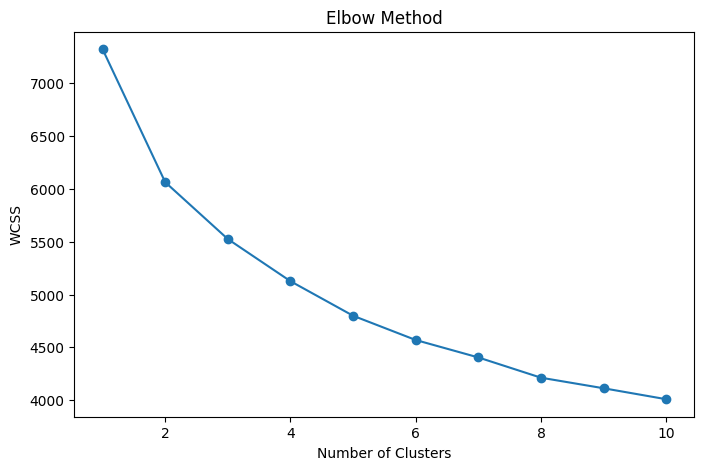

In [32]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [33]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

In [34]:
df['Cluster'] = clusters

In [35]:
df.head()

,Unnamed: 0.1,Sentiment,Platform,Retweets,Likes,Country,Year,Month,Day,Hour,Cluster
0,0,214,3,15.0,30.0,106,2023,1,15,12,2
1,1,195,3,5.0,10.0,20,2023,1,15,8,2
2,2,214,1,20.0,40.0,108,2023,1,15,15,2
3,3,214,0,8.0,15.0,91,2023,1,15,18,2
4,4,197,1,12.0,25.0,0,2023,1,15,19,2


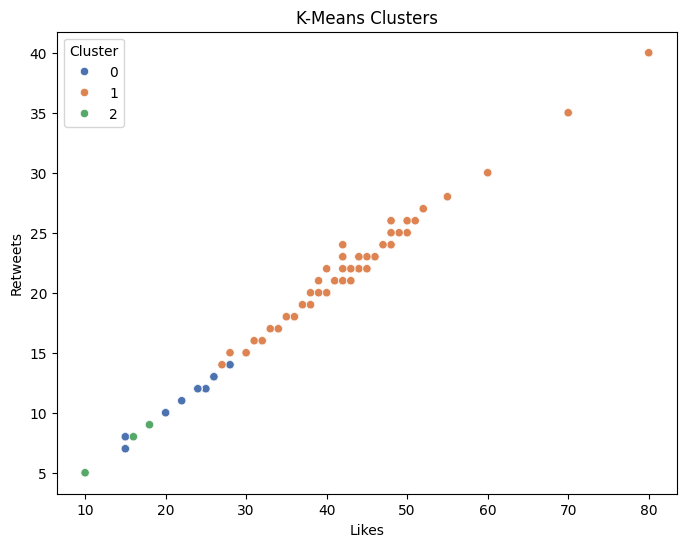

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Likes'],
    y=df['Retweets'],
    hue=df['Cluster'],
    palette='deep'
)

plt.title("K-Means Clusters")

plt.show()

In [37]:
cluster_summary = df.groupby('Cluster').mean()

print(cluster_summary)

         Unnamed: 0.1   Sentiment  Platform   Retweets      Likes    Country  \
Cluster                                                                        
0          288.067873  130.470588  1.235294  17.167421  34.312217  51.710407   
1          555.326019  144.012539  1.015674  26.429467  52.586207  64.576803   
2          142.916667  138.223958  1.364583  18.328125  36.697917  66.218750   

                Year     Month        Day       Hour  
Cluster                                               
0        2018.176471  8.217195  14.497738  15.113122  
1        2021.059561  7.028213  15.225705  17.153605  
2        2022.135417  2.208333  17.098958  13.281250  
